# Structural robustness of mammalian transcription factor networks reveals plasticity across development

## Mouse Analysis

### External imports

In [3]:
import os
import pandas as pd
from io import BytesIO
import networkx as nx
from PIL import Image
import inspect
import numpy as np
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from itertools import chain
import re
import time
import random

### Extracción de las redes

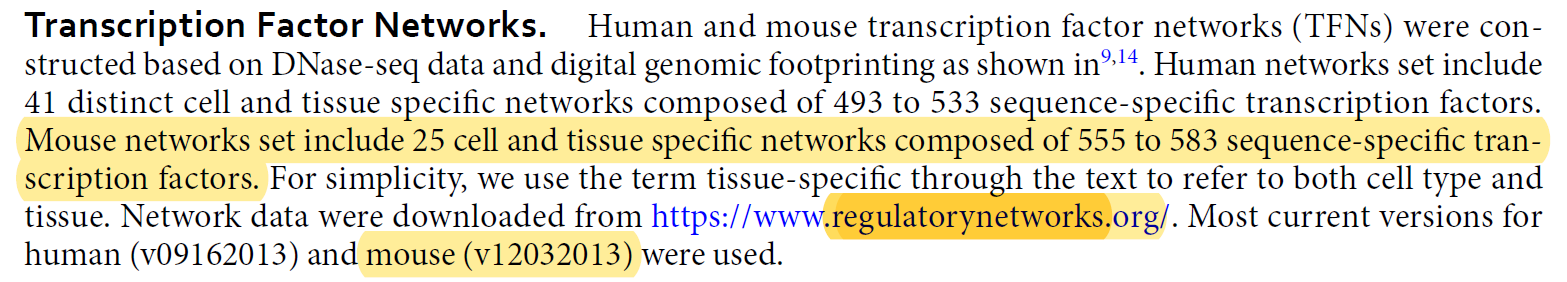

#### Auxiliar Fxns

In [4]:
def get_mouse_names(root, code_names):
    name = re.split('mouse_net', root)
    name = name[1]
    name = name.replace('/','')
    return code_names[name]

In [5]:
def extract_networks(directory_name=str, files_ignore=list, cols=tuple, feo=True, code_names=dict):
    networks = {}
    for root, dir, files in os.walk(directory_name):
        if len(files) != 0 and files[0] not in files_ignore:
          path = os.path.join(os.getcwd(), root, files[0])
          net = nx.DiGraph()
          if feo:
               f = np.genfromtxt(path, dtype= str, delimiter='\t', usecols= cols)
               net.add_edges_from(f)
          else:
               net = nx.read_edgelist(path)
          name = get_mouse_names(root, code_names)
          networks[name] = net
    return networks

#### Biological Networks

In [6]:
mm9CellTypeValues = { "m3134-DS8497" : 			  "mammary adenocarcinoma",
                        "m416B-DS14099" : 		  "CD34+ myeloid progenitor",
                        "mA20-DS16695" :            "B-lymphocyte reticulum cell sarcoma",
                        "mATn-DS17070" :            "activated T-naive cell",
                        "mATr-DS20149" :            "ATr",
                        "mB-DS16168" :              "B-cell, replicate 1",
                        "mB-DS17866" :              "B-cell, replicate 2",
                        "mBrain-DS12727" :          "normal brain",
                        "mCJ7-DS13320" :            "embryonic stem cells via 129S1/SVImJ mice",
                        "MEL-DS13036" :             "leukemia, K562 analog",
                        "mfBrain-DS14536" :         "fetal brain",
                        "mGenitalFatPad-DS18182" :  "genital adipose tissue",
                        "mHeart-DS18138" :          "normal heart",
                        "mKidney-DS13948" :         "normal kidney",
                        "mLiver-DS14605" :          "normal liver",
                        "mLung-DS14479" :           "normal lung",
                        "mNIH_3T3-DS16900" :        "fibroblast",
                        "mRetina-DS20004" :         "normal retina", 
                        "mThymus-DS18819" :         "normal thymus",
                        "mTN-DS16171" :             "TN, replicate 1",
                        "mTN-DS17080" :             "TN, replicate 2",
                        "mTR-DS17864" :             "regulatory T-cells",
                        "ZhBTc4-DS15236" :          "embryonic stem cells, +6 hrs doxycycline",
                        "ZhBTc4-DS17562" :          "embryonic stem cells, +24 hrs doxycycline",
                        "ZhBTc4-DS17616" :          "embryonic stem cells, control"
                        }

mouse_networks = extract_networks('./../../data/mouse_net/', [], (3,4), feo=True, code_names=mm9CellTypeValues)

#### Synthetic networks

ER and BA analogous ensembles to each biological network.

from freyrelab.nets import models

seed = 42
synth_graphs = {}

for net_id, G in mouse_networks.items():
    n = G.number_of_nodes()
    m = G.number_of_edges()
    for i in range(1,101):
        synth_graphs[f'BA_{net_id}_{i}'] = nx.DiGraph(models.barabasi_albert_graph(n))
        synth_graphs[f'ER_{net_id}_{i}'] = nx.erdos_renyi_graph(n, m/(n*(n-1)), seed=seed, directed=True)

networks = {**mouse_networks, **synth_graphs}

#### Graphs overall info

In [7]:
nets_info = {'Cell Type': [],
        'Nodes': [],
        'Edges': [],
        'Density': []
        }

for name,G in mouse_networks.items():
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = n_edges / (n_nodes * (n_nodes - 1))
    nets_info['Cell Type'].append(name)
    nets_info['Nodes'].append(n_nodes)
    nets_info['Edges'].append(n_edges)
    nets_info['Density'].append(density)

info_df = pd.DataFrame.from_dict(nets_info)
info_df

,Cell Type,Nodes,Edges,Density
0,mammary adenocarcinoma,568,22301,0.069246
1,CD34+ myeloid progenitor,570,18299,0.056421
2,B-lymphocyte reticulum cell sarcoma,571,20363,0.062565
3,activated T-naive cell,579,28185,0.084219
4,ATr,575,21445,0.064975
5,"B-cell, replicate 1",574,22119,0.067251
6,"B-cell, replicate 2",555,15565,0.050623
7,normal brain,562,15652,0.049644
8,embryonic stem cells via 129S1/SVImJ mice,579,20335,0.060763
9,"leukemia, K562 analog",568,20563,0.063849


### Netective Analysis

In [8]:
from netective.structure.structure import compare_structure

`!!!!AGUAS!!!!`

In [9]:
test = {
    net_name : net
    for i,(net_name, net) in enumerate(mouse_networks.items())
    if i < 2
}
test

{'mammary adenocarcinoma': <networkx.classes.digraph.DiGraph at 0x1db76c922b0>,
 'CD34+ myeloid progenitor': <networkx.classes.digraph.DiGraph at 0x1db76cecd60>}

[get_props] [WARNING] [The network or the normalization method has changed. Computing its properties...]
[INFO] Processing ER...
[INFO] ER has 100 nodes and 2996 edges.


[10/15/2023 07:01:43 PM] [structure] [_compute_props] [557] [Starting properties computation...]
[10/15/2023 07:01:43 PM] [structure] [_compute_props] [563] [Finished computing: Average Degree for Nearest Neighbors (Undirected)]
[10/15/2023 07:01:43 PM] [structure] [_compute_props] [563] [Finished computing: Clustering Coefficient]
[10/15/2023 07:01:43 PM] [structure] [_compute_props] [563] [Finished computing: Rich Club Coefficient]
[10/15/2023 07:01:44 PM] [structure] [_compute_props] [563] [Finished computing: Average Local Efficiency]
[10/15/2023 07:01:44 PM] [structure] [_compute_props] [563] [Finished computing: Average Shortest Path Length]
[10/15/2023 07:01:44 PM] [structure] [_compute_props] [563] [Finished computing: Betweenness Centrality]
[10/15/2023 07:01:44 PM] [structure] [_compute_props] [563] [Finished computing: Center]
[10/15/2023 07:01:44 PM] [structure] [_compute_props] [563] [Finished computing: Diameter]
[10/15/2023 07:01:44 PM] [structure] [_compute_props] [563]

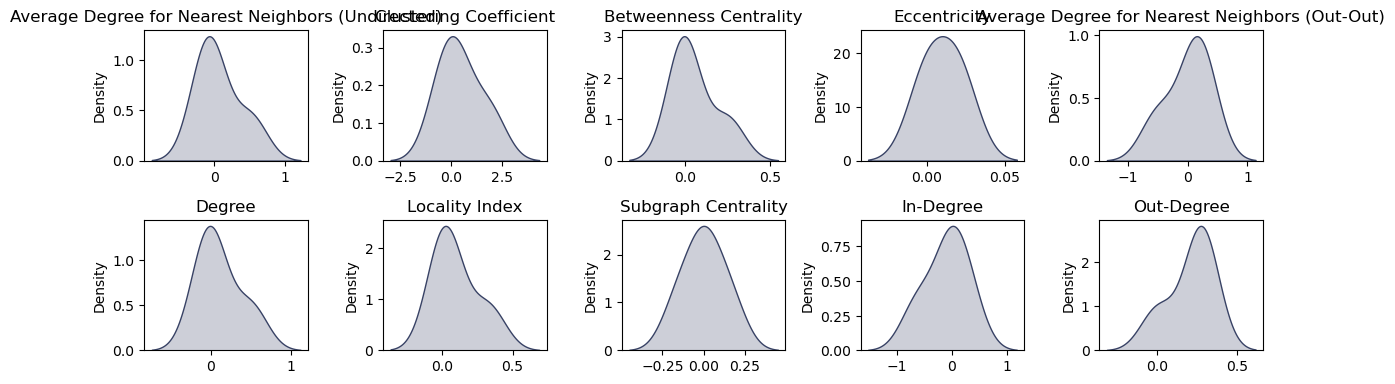

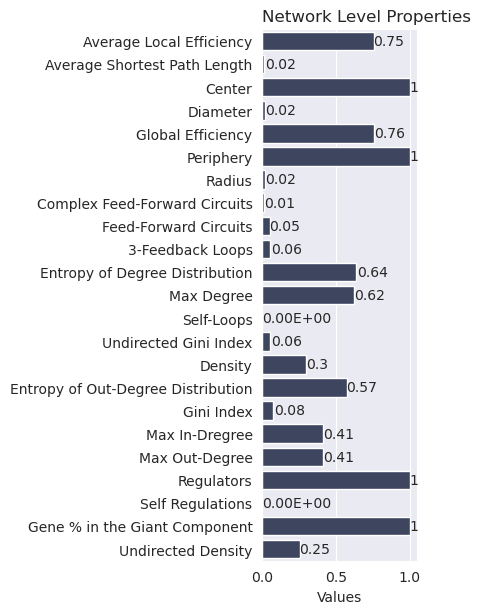

In [2]:
import networkx as nx
from netective import characterize_network
from netective.structure.structure import set_log_level

er_1 = nx.erdos_renyi_graph(n= 100, p=0.3, directed=True)
set_log_level('info')
characterize_network(G= er_1, name= 'ER', norm= 'network', verbose='debug')

[INFO] Starting analysis of inputed networks...


  0%|          | 0/2 [00:00<?, ?it/s]

[INFO] Running mammary adenocarcinoma...
[INFO] Running CD34+ myeloid progenitor...
[INFO] Finilized: CD34+ myeloid progenitor


 50%|█████     | 1/2 [00:28<00:28, 28.90s/it]

[INFO] Finilized: mammary adenocarcinoma


100%|██████████| 3/3 [00:19<00:00,  6.52s/it]


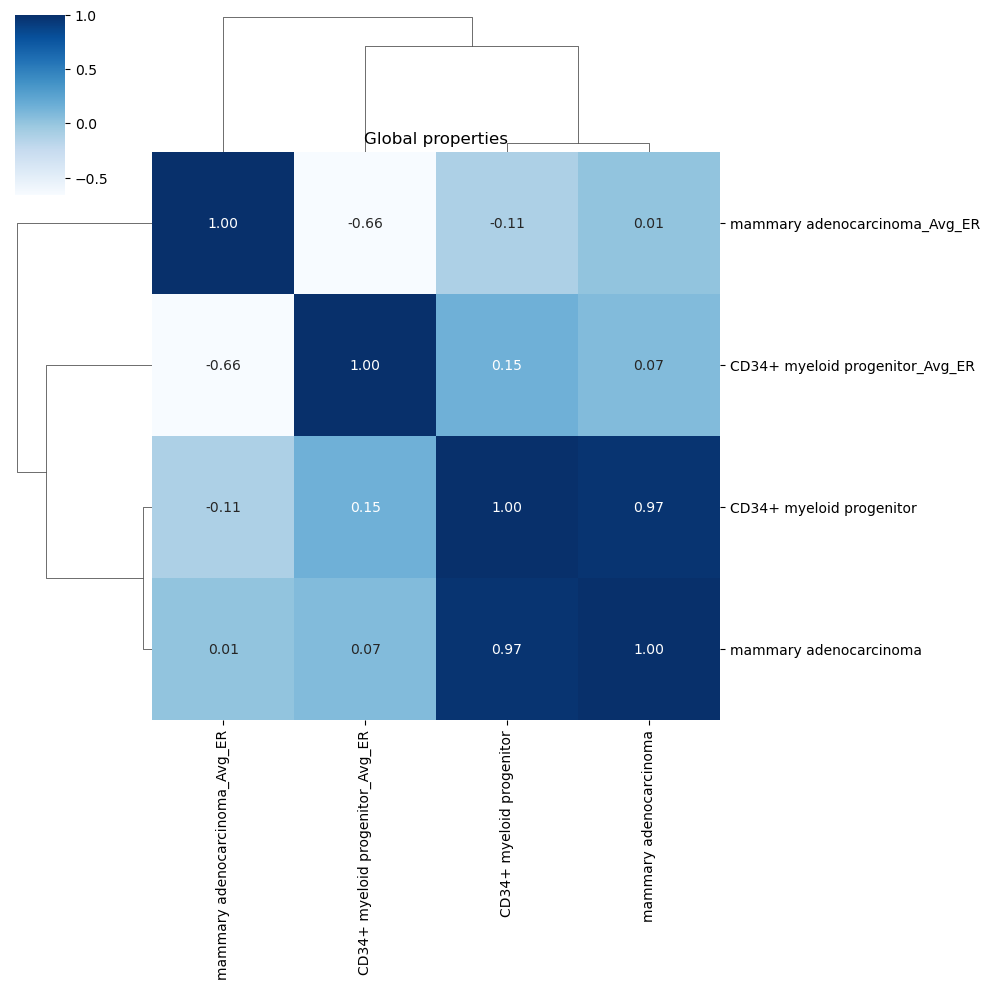

In [10]:
import networkx as nx
from netective import compare_structure
nets = {
    'pepe' : nx.erdos_renyi_graph(n= 100, p=0.3, directed=True),
    'juan' : nx.erdos_renyi_graph(n= 100, p=0.4, directed=True)
}
compare_structure(test, workers=4, norm='network', return_prop_dicts= False, erdos_renyi=3, verbose='debug');


In [25]:
distribuciones = {
    'net_1' : {
        'Out Degree' : [1,2,3,4],
        'In Degree' : [5,6,7,8],
        'Degree' : [9,10,11,12]
    },
    'net_2' : {
        'Out Degree' : [1,2,3,4],
        'In Degree' : [5,6,7,8],
        'Degree' : [9,10,11,12]
    }
}

properties = {}
for i, (net_name, prop)  in enumerate(distribuciones.items()):
    for j, (prop_name, values) in enumerate(prop.items()):
        if i == 0:
            properties[prop_name] = {
                'Average' : [],
                'Variation' : [],
                'Skewness' : [],
                'Kurtosis' : []
            }
        for k, value in enumerate(values):
            if k == 0:
                moment = 'Average'
            elif k == 1:
                moment = 'Variation'
            elif k == 2:
                moment = 'Skewness'
            elif k == 3:
                moment = 'Kurtosis'
            properties[prop_name][moment].append(value)

properties


{'Out Degree': {'Average': [1, 1],
  'Variation': [2, 2],
  'Skewness': [3, 3],
  'Kurtosis': [4, 4]},
 'In Degree': {'Average': [5, 5],
  'Variation': [6, 6],
  'Skewness': [7, 7],
  'Kurtosis': [8, 8]},
 'Degree': {'Average': [9, 9],
  'Variation': [10, 10],
  'Skewness': [11, 11],
  'Kurtosis': [12, 12]}}

In [26]:
final = {}
for prop_name, moments in properties.items():
    final[prop_name] = []
    for moment, values in moments.items():
        avg = sum(values) / len(values)
        final[prop_name].append(avg)
final

{'Out Degree': [1.0, 2.0, 3.0, 4.0],
 'In Degree': [5.0, 6.0, 7.0, 8.0],
 'Degree': [9.0, 10.0, 11.0, 12.0]}